# INFERENCE YOLO

Notebook ini memakai model hasil training dari `03_train_yolo.ipynb` untuk deteksi plat pada data test, lalu menyimpan gambar anotasi, crop plat, dan tabel prediksi.


# Import Library


In [29]:
from ultralytics import YOLO
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load Model


In [30]:
MODEL_PATH = "../runs/outputs/plat_detector/weights/best.pt"

assert Path(MODEL_PATH).exists(), "Model best.pt tidak ditemukan"

model = YOLO(MODEL_PATH)

print("Model berhasil dimuat.")

Model berhasil dimuat.


# Pilih Gambar


In [31]:
IMAGE_PATH = "../datasets/anpr-model-1.v1i.yolov11/test/images"

image_files = sorted(Path(IMAGE_PATH).glob("*"))

print(f"Jumlah gambar : {len(image_files)}")

sample = image_files[0]

print(sample)

Jumlah gambar : 96
../datasets/anpr-model-1.v1i.yolov11/test/images/0f758-polri_jpg.rf.7c7e1d400974e0c72bd40c9e2f491be4.jpg


# Show Image


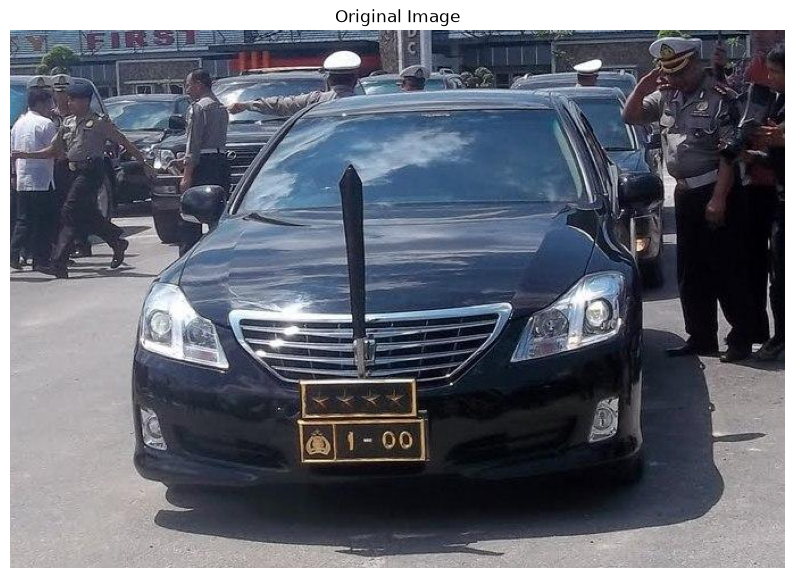

In [32]:
image = cv2.imread(str(sample))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(image)
plt.axis("off")
plt.title("Original Image")
plt.show()

# deteksi plat


In [33]:
results = model.predict(
    source=str(sample),
    conf=0.25,
    save=False
)


image 1/1 /home/betenk/Documents/Porto/notebooks/../datasets/anpr-model-1.v1i.yolov11/test/images/0f758-polri_jpg.rf.7c7e1d400974e0c72bd40c9e2f491be4.jpg: 448x640 2 plates, 27.7ms
Speed: 2.2ms preprocess, 27.7ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


# Visualisasi Hasil


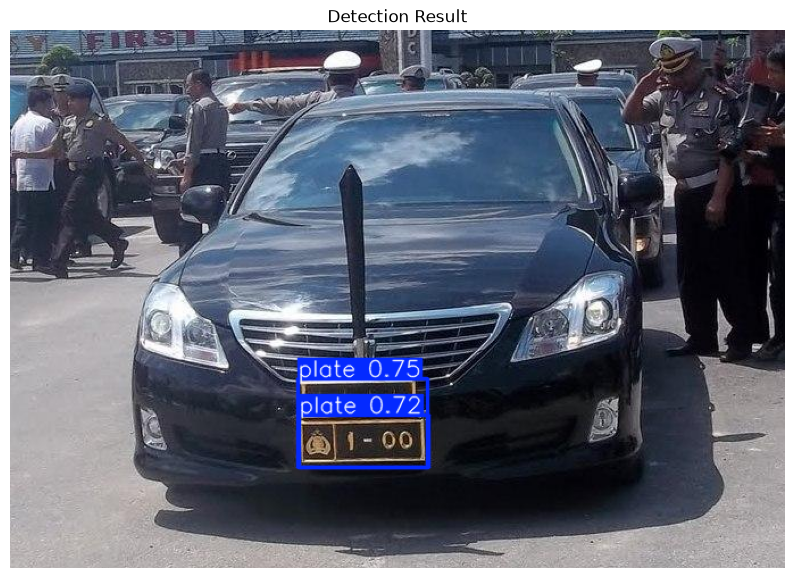

In [34]:
result = results[0]

annotated = result.plot()

annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,8))
plt.imshow(annotated)
plt.axis("off")
plt.title("Detection Result")
plt.show()

# Bounding Box


In [35]:
boxes = result.boxes

print("Jumlah Deteksi :", len(boxes))
for i, box in enumerate(boxes):

    xyxy = box.xyxy[0].cpu().numpy()

    conf = float(box.conf[0])

    cls = int(box.cls[0])

    print("="*40)
    print(f"Object {i+1}")
    print("Class      :", cls)
    print("Confidence :", round(conf,3))
    print("Bounding Box :", xyxy)

Jumlah Deteksi : 2
Object 1
Class      : 0
Confidence : 0.746
Bounding Box : [     253.66      306.43      367.23      384.78]
Object 2
Class      : 0
Confidence : 0.722
Bounding Box : [     254.46       338.6      368.32      384.07]


# Tampilkan Hasil crop


In [36]:
plate_images = []

image_bgr = cv2.imread(str(sample))

if image_bgr is None:
    raise ValueError("Gagal membaca gambar")

for box in boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

    crop = image_bgr[y1:y2, x1:x2]

    plate_images.append(crop)

print(f"Jumlah crop: {len(plate_images)}")

Jumlah crop: 2


# Simpan Crop

In [ ]:
SAVE_DIR = Path("../outputs/images")

SAVE_DIR.mkdir(parents=True, exist_ok=True)

for i, crop in enumerate(plate_images):

    filename = SAVE_DIR / f"plate_{i+1}.jpg"

    cv2.imwrite(str(filename), crop)

print("Crop berhasil disimpan.")

Crop berhasil disimpan.


: 